In [41]:
import numpy as np
from scipy.stats import uniform, norm, chi2
import astropy.units as u
import matplotlib.pyplot as plt

import imfs
import rv_simu


In [150]:
# We want to make a realistic model of how RVs were calculated
numnights = 14
nightnumbers = np.arange(numnights) * u.day
night_frac = 0.2
time_of_night = uniform.rvs(scale=night_frac, size=numnights)*u.day
observed_time = nightnumbers + time_of_night

In [160]:
amp = 20*u.km/u.s
period = 1.9*u.day
phase= 2*np.pi*uniform.rvs() * u.rad
true_rv_curve = rv_simu.sample_RV_curve(observed_time, amp, period, phase)
noise = 10 * u.km / u.s
measured_rv_curve = true_rv_curve + noise*norm.rvs(size=len(true_rv_curve))

<Container object of 3 artists>

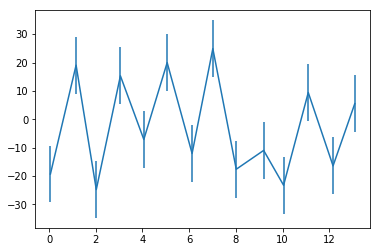

In [161]:
plt.errorbar(observed_time.to(u.day).value, measured_rv_curve.to(u.km/u.s).value, yerr=noise.to(u.km/u.s).value)

In [162]:
mean_rv = np.mean(measured_rv_curve)
chi_sq = np.sum((measured_rv_curve-mean_rv)**2 / noise**2)
prob_greater = 1 - chi2.cdf(chi_sq, len(measured_rv_curve)-1)

In [163]:
print(chi_sq)
print(prob_greater)

40.53946896140374
0.00011313680184854569


In [168]:
phivals = np.linspace(0, 1) * np.pi * 2
rvkfrac = 1.0
wt = 4*np.pi + 0.3
nval = np.trunc(wt / (2 * np.pi))

2.0